In [6]:
# importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Loading dataset
df = pd.read_csv("sales_data.csv")
# understanding data
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 Rows:")
df.head()

Shape: (9800, 18)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# now checking missing values and basic stats
print(df.dtypes)
print(df.isnull().sum())

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [8]:
# almost clean data only postal code
# Filling missing postal code
df['Postal Code'] = df['Postal Code'].fillna(0).astype(int).astype(str).str.zfill(5)

In [11]:
# changing date format to add some columns
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [12]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%B')
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [13]:
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nNew columns added:", ['Order Year', 'Order Month', 'Order Month Name', 'Delivery Days'])
print("\nSample Delivery Days:", df['Delivery Days'].describe())

Missing values after cleaning:
Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Order Year          0
Order Month         0
Order Month Name    0
Delivery Days       0
dtype: int64

New columns added: ['Order Year', 'Order Month', 'Order Month Name', 'Delivery Days']

Sample Delivery Days: count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Delivery Days, dtype: float64


In [14]:
# some Basic Statistics
print("=== Sales Statistics ===")
print(df['Sales'].describe())

print("\n=== Sales by Category ===")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

print("\n=== Sales by Region ===")
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False))

print("\n=== Sales by Segment ===")
print(df.groupby('Segment')['Sales'].sum().sort_values(ascending=False))

print("\n=== Sales by Year ===")
print(df.groupby('Order Year')['Sales'].sum().sort_values(ascending=False))

=== Sales Statistics ===
count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

=== Sales by Category ===
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

=== Sales by Region ===
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

=== Sales by Segment ===
Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

=== Sales by Year ===
Order Year
2018    722052.0192
2017    600192.5500
2015    479856.2081
2016    459436.0054
Name: Sales, dtype: float64


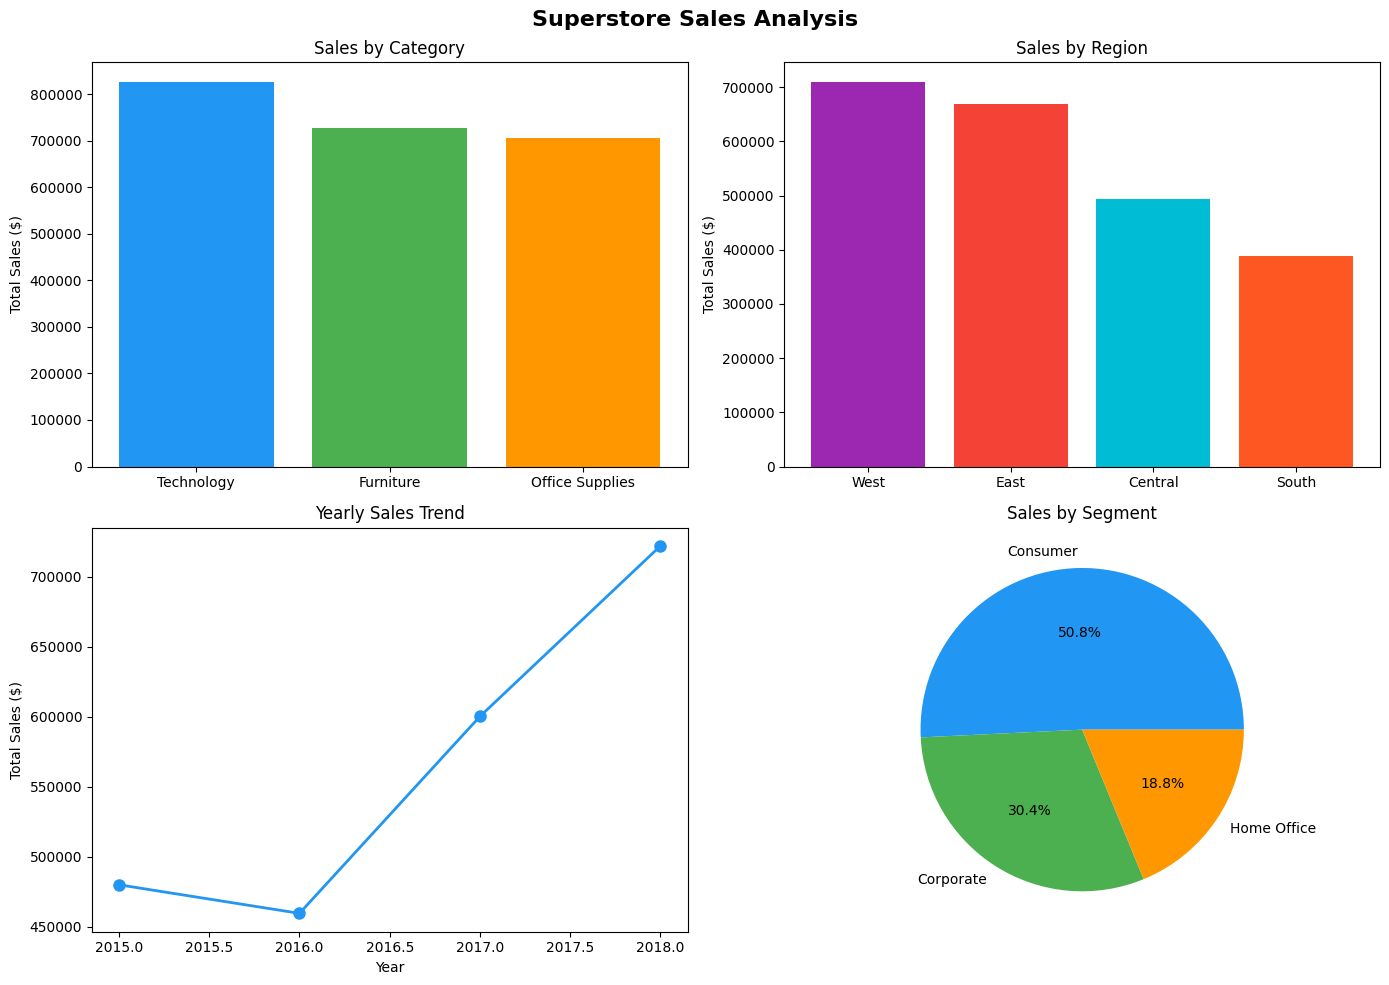

Chart saved as sales_analysis.png


In [15]:
#- Visualizations -
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superstore Sales Analysis', fontsize=16, fontweight='bold')

# Plot 1 - Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0,0].bar(category_sales.index, category_sales.values, color=['#2196F3','#4CAF50','#FF9800'])
axes[0,0].set_title('Sales by Category')
axes[0,0].set_ylabel('Total Sales ($)')

# Plot 2 - Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0,1].bar(region_sales.index, region_sales.values, color=['#9C27B0','#F44336','#00BCD4','#FF5722'])
axes[0,1].set_title('Sales by Region')
axes[0,1].set_ylabel('Total Sales ($)')

# Plot 3 - Yearly Sales Trend
yearly_sales = df.groupby('Order Year')['Sales'].sum()
axes[1,0].plot(yearly_sales.index, yearly_sales.values, marker='o', color='#2196F3', linewidth=2, markersize=8)
axes[1,0].set_title('Yearly Sales Trend')
axes[1,0].set_ylabel('Total Sales ($)')
axes[1,0].set_xlabel('Year')

# Plot 4 - Sales by Segment
segment_sales = df.groupby('Segment')['Sales'].sum()
axes[1,1].pie(segment_sales.values, labels=segment_sales.index, autopct='%1.1f%%', colors=['#2196F3','#4CAF50','#FF9800'])
axes[1,1].set_title('Sales by Segment')

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as sales_analysis.png")

In [17]:
# Clean Column Names
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')

print("Updated column names:")
print(list(df.columns))

Updated column names:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'order_year', 'order_month', 'order_month_name', 'delivery_days']


In [18]:
# To Export Clean Data for Power BI
df.to_csv('superstore_cleaned.csv', index=False)
print("✅ Clean data exported successfully!")
print("File: superstore_cleaned.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

✅ Clean data exported successfully!
File: superstore_cleaned.csv
Shape: (9800, 22)
Columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'order_year', 'order_month', 'order_month_name', 'delivery_days']
